In [9]:
import kagglehub
import pandas as pd
import os
import tensorflow as tf
import numpy as np
# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")




print("Path to dataset files:", path)


train_data =os.path.join(path, "sign_mnist_train.csv")
test_data = os.path.join(path, "sign_mnist_test.csv")

train_df = pd.read_csv(train_data)
test_df = pd.read_csv(test_data)

print(train_df.head())




Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Path to dataset files: /kaggle/input/sign-language-mnist
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        

In [13]:
from sklearn.preprocessing import StandardScaler

y_train = train_df["label"].to_numpy()
y_test  = test_df["label"].to_numpy()
X_train = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32)
X_test  = test_df.drop(columns=["label"]).to_numpy(dtype=np.float32)


scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test  = scaler.transform(x_test)


In [20]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=200, solver="lbfgs", multi_class="multinomial", n_jobs=-1)
clf.fit(X_train, y_train)

print("Train acc:", clf.score(X_train, y_train))
print("Test acc:", clf.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train acc: 1.0
Test acc: 0.6866982710540993


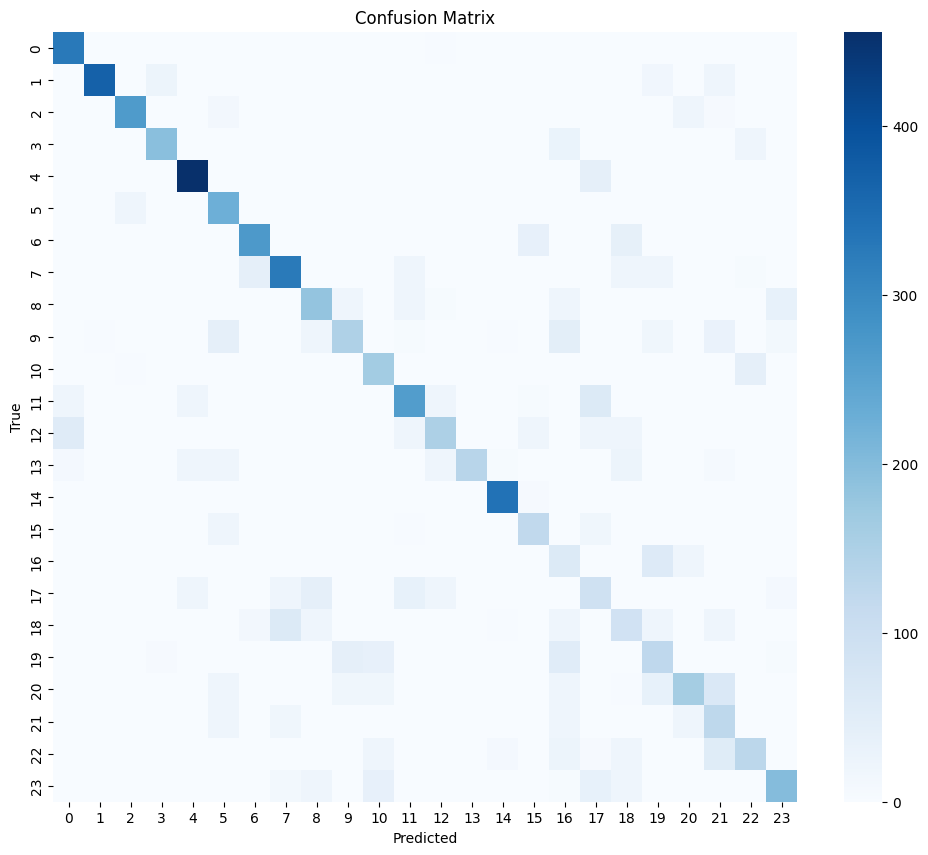

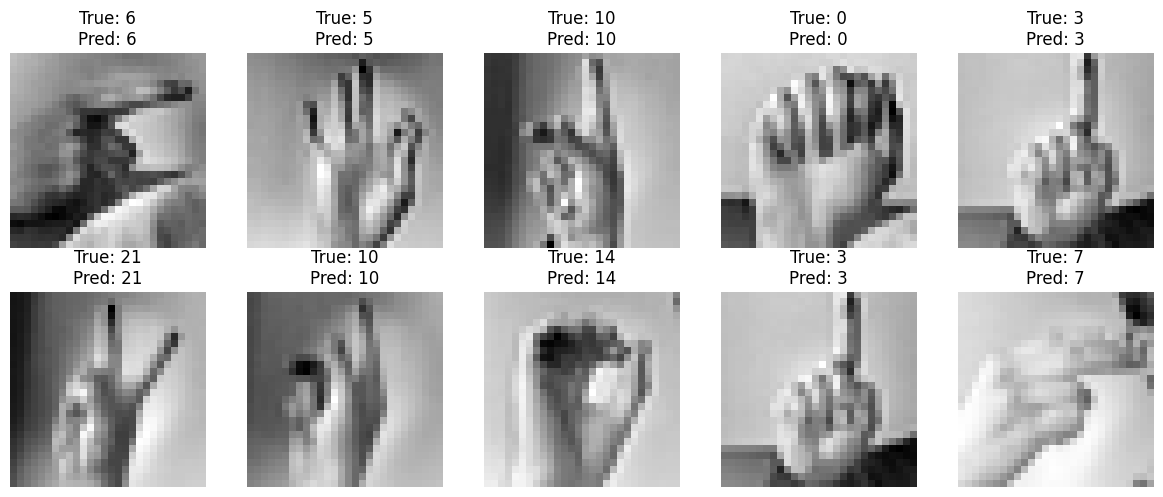

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    img = X_test[i].reshape(28,28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()